# Exploratory Data Analysis (EDA) — PdM_errors.csv

# 1 ) Introduction

## 1.1 Error Log Analysis
Dataset

Microsoft Azure Predictive Maintenance Dataset

Goal

To analyze machine error logs and identify error patterns, frequency, machine-wise error occurrences, and operational anomalies that may contribute to machine failures.

## 1.2 Dataset Feature Description
datetime
→ Timestamp when the error occurred

machineID
→ Unique machine identifier

errorID
→ Error type generated by the machine

## 1.3 Business Objective

The objective of this analysis is to understand machine error behavior and identify recurring error patterns. The insights obtained will help in detecting potential failure indicators and improving predictive maintenance strategies.

# 2 ) Data Understanding


## 2.1 Library Import

In [2]:

# Import Required Libraries

# Data Manipulation Libraries

import pandas as pd
import numpy as np

# Visualization Libraries

import matplotlib.pyplot as plt
import seaborn as sns

# Ignore Warnings

import warnings
warnings.filterwarnings('ignore')

# Display All Columns

pd.set_option('display.max_columns', None)

# Set Plot Style

sns.set_style('whitegrid')

# Inline Plot Display

%matplotlib inline

* Required libraries have been successfully imported.
* Pandas and NumPy will be used for data manipulation and analysis.
* Matplotlib and Seaborn will be used for data visualization.
* Warning messages have been suppressed for cleaner notebook output.

## 2.2 Load Dataset

In [3]:
# Load Error Dataset

errors = pd.read_csv("PdM_errors.csv")

errors.head()

,datetime,machineID,errorID
0,2015-01-03 07:00:00,1,error1
1,2015-01-03 20:00:00,1,error3
2,2015-01-04 06:00:00,1,error5
3,2015-01-10 15:00:00,1,error4
4,2015-01-22 10:00:00,1,error4


* Dataset contains machine error records.
* Each row represents an error event generated by a machine.
* Five different error categories are present.

## 2.3 Dataset Information

In [4]:
errors.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3919 entries, 0 to 3918
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   datetime   3919 non-null   object
 1   machineID  3919 non-null   int64 
 2   errorID    3919 non-null   object
dtypes: int64(1), object(2)
memory usage: 92.0+ KB


* Dataset contains 3919 error records.
* Three features are available.
* Error information is stored as categorical data.

## 2.4 Dataset Shape

In [5]:
print("Rows :", errors.shape[0])
print("Columns :", errors.shape[1])

Rows : 3919
Columns : 3


* Dataset contains 3919 observations and 3 features.
* Error logs provide historical machine fault information

# 3 ) Missing Value Analysis


## 3.1 Missing Values

In [6]:
errors.isnull().sum()

,0
datetime,0
machineID,0
errorID,0


* No missing values are present.
* Error logs appear complete and reliable.

# 4 ) Duplicate Analysis


## 4.1 Duplicate Records

In [7]:
duplicates = errors.duplicated().sum()

print("Duplicates :", duplicates)

Duplicates : 0


* Duplicate error entries can indicate repeated machine events.
* Further investigation may be required if duplicates exist.

# 5 ) Error Distribution Analysis


## 5.1 Error Frequency Distribution

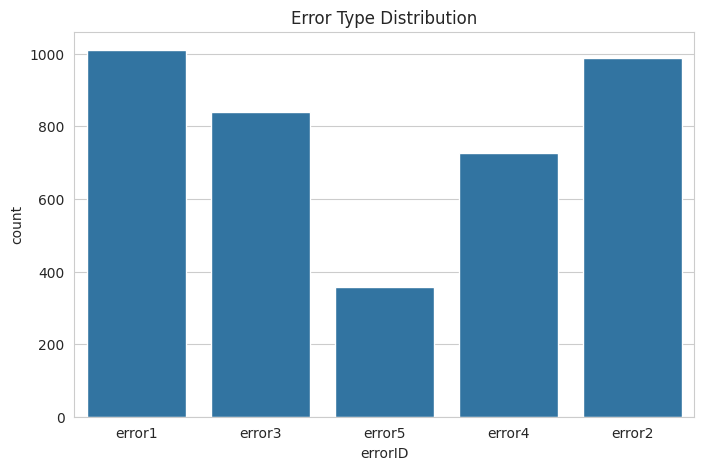

In [8]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='errorID',
    data=errors
)

plt.title("Error Type Distribution")

plt.show()

* Error occurrences are not evenly distributed.
* Some error types occur more frequently than others.

## 5.2 Error Percentage Analysis

In [9]:
error_percent = (

    errors['errorID']
    .value_counts(normalize=True)

    * 100

)

error_percent

,proportion
errorID,
error1,25.771881
error2,25.210513
error3,21.383006
error4,18.550651
error5,9.083950


* Certain error types contribute a larger percentage of total errors.
* Error frequency varies across categories.

# 6 ) Machine-wise Error Analysis


## 6.1 Top 10 Machines with Highest Errors

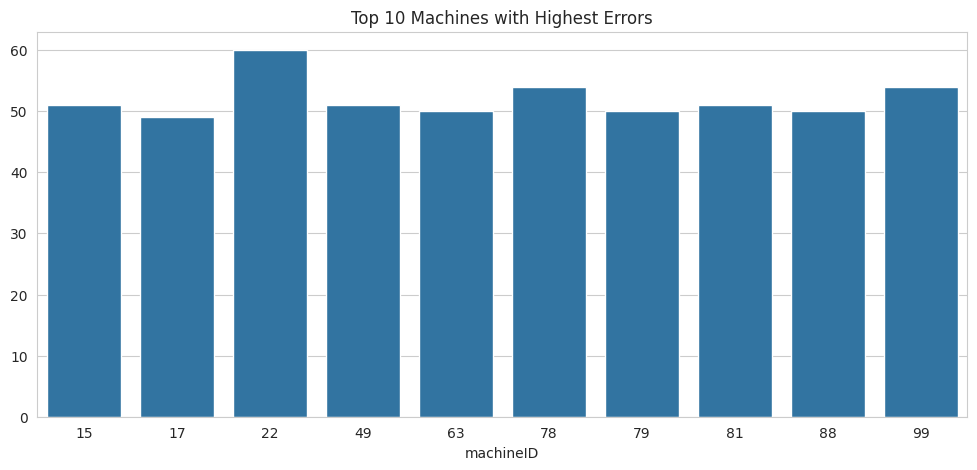

In [10]:
top_error_machines = (

    errors['machineID']
    .value_counts()
    .head(10)

)

plt.figure(figsize=(12,5))

sns.barplot(
    x=top_error_machines.index,
    y=top_error_machines.values
)

plt.title("Top 10 Machines with Highest Errors")

plt.show()

* Some machines generate significantly more errors.
* Error concentration is not uniform across machines.

## 6.2 Error Count per Machine

In [11]:
machine_error_count = (

    errors.groupby('machineID')
    .size()

)

machine_error_count.head()

,0
machineID,
1,35
2,28
3,39
4,31
5,38


* Error frequency differs among machines.
* Certain machines show abnormal error behavior.

# 7 ) Error Trend AnalysisA



## 7.1 Datetime Conversion

In [12]:
errors['datetime'] = pd.to_datetime(
    errors['datetime']
)

* Datetime successfully converted.
* Time-based analysis can now be performed.

## 7.2 Error Occurrence Over Time

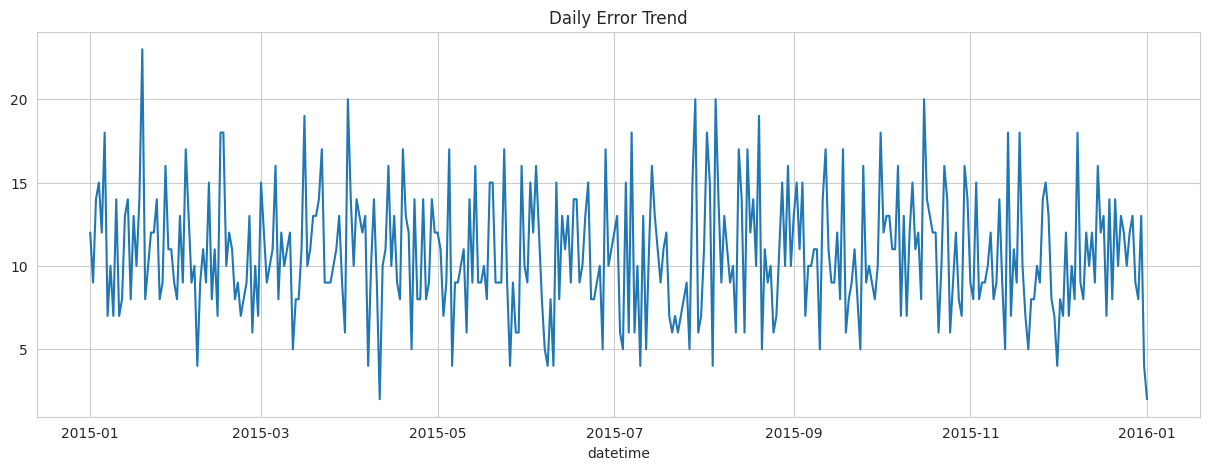

In [13]:
daily_errors = (

    errors
    .groupby(
        errors['datetime'].dt.date
    )
    .size()

)

plt.figure(figsize=(15,5))

daily_errors.plot()

plt.title(
    "Daily Error Trend"
)

plt.show()

* Error occurrences fluctuate over time.
* Certain periods exhibit higher error activity.

# 8 ) Error Type Analysis


## 8.1 Error-wise Frequency

In [14]:
errors['errorID'].value_counts()

,count
errorID,
error1,1010
error2,988
error3,838
error4,727
error5,356


* Five unique error types are present.
* Error distribution differs significantly.

## 8.2 Pie Chart of Errors

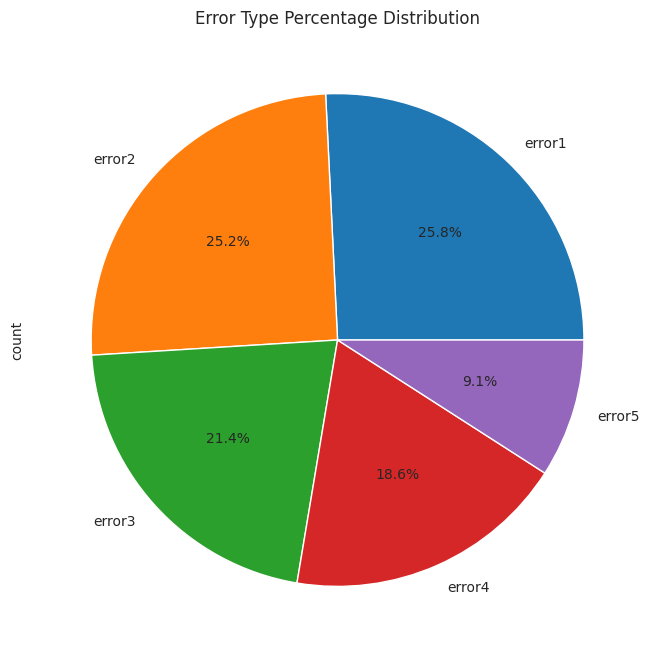

In [15]:
errors['errorID'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    figsize=(8,8)
)

plt.title(
    "Error Type Percentage Distribution"
)

plt.show()

* Error contribution of each category becomes more visible.
* Some errors dominate the dataset.

## 8.3 Most Frequent Error

In [17]:
errors.groupby(
'machineID'
).size().sort_values(
ascending=False
).head(20)

,0
machineID,
22,60
99,54
78,54
15,51
81,51
49,51
63,50
79,50
88,50


## 8.4 Machine vs Error Type Heatmap

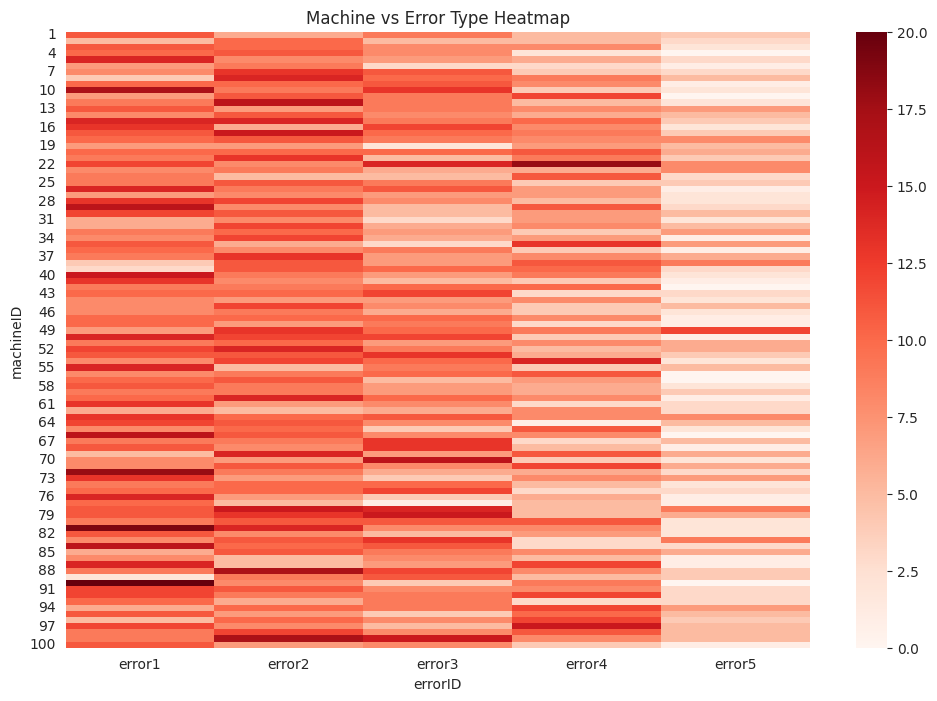

In [19]:
error_pivot = pd.crosstab(
    errors['machineID'],
    errors['errorID']
)

plt.figure(figsize=(12,8))

sns.heatmap(
    error_pivot,
    cmap='Reds'
)

plt.title("Machine vs Error Type Heatmap")

plt.show()

*Some machines experience specific error types more frequently.
* Error distribution is not uniform across machines.

## 8.5 Error Risk Score Analysis

In [22]:
error_count = (
    errors.groupby('machineID')
    .size()
)

risk_score = (
    error_count
    /
    error_count.max()
) * 100

risk_score.sort_values(
    ascending=False
).head(10)

,0
machineID,
22,100.000000
99,90.000000
78,90.000000
15,85.000000
81,85.000000
49,85.000000
63,83.333333
79,83.333333
88,83.333333


* Machines receive different risk scores based on error occurrence.
* High-risk machines are easily identifiable.